In [ ]:
import pandas as pd
import numpy as np


df = pd.read_csv(
    '/content/CEAS_08.csv',
    engine='python',
    on_bad_lines='skip'
)


df.head()

,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


In [ ]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nLabel distribution:")
print(df['label'].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (36066, 7)

Columns:
['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']

Label distribution:
label
1    20004
0    16062
Name: count, dtype: int64

Missing values:
sender        0
receiver    443
date          0
subject      27
body          0
label         0
urls          0
dtype: int64


In [ ]:

print("Unique labels:", df['label'].unique())

print("\nLabel counts:")
print(df['label'].value_counts())

Unique labels: [1 0]

Label counts:
label
1    20004
0    16062
Name: count, dtype: int64


In [ ]:

df['subject'] = df['subject'].fillna('')
df['body'] = df['body'].fillna('')

df['text'] = df['subject'] + ' ' + df['body']


df[['text', 'label']].head()

,text,label
0,"Never agree to be a loser Buck up, your troubl...",1
1,Befriend Jenna Jameson \nUpgrade your sex and ...,1
2,CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...,1
3,Re: svn commit: r619753 - in /spamassassin/tru...,0
4,SpecialPricesPharmMoreinfo \nWelcomeFastShippi...,1


In [ ]:

data = df[['text', 'label']].copy()


data = data[data['text'].str.strip() != '']


data = data.reset_index(drop=True)

print("Final dataset size:", data.shape)
print(data.head())

Final dataset size: (36066, 2)
                                                text  label
0  Never agree to be a loser Buck up, your troubl...      1
1  Befriend Jenna Jameson \nUpgrade your sex and ...      1
2  CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...      1
3  Re: svn commit: r619753 - in /spamassassin/tru...      0
4  SpecialPricesPharmMoreinfo \nWelcomeFastShippi...      1


In [ ]:
import re

def clean_text(text):
    text = str(text).lower()                 # Convert to lowercase
    text = re.sub(r'http\S+|www\S+', ' URL ', text)  # Replace URLs
    text = re.sub(r'<.*?>', ' ', text)       # Remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', ' ', text) # Remove special characters/numbers
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    return text

data['clean_text'] = data['text'].apply(clean_text)


data[['text', 'clean_text', 'label']].head()

,text,clean_text,label
0,"Never agree to be a loser Buck up, your troubl...",never agree to be a loser buck up your trouble...,1
1,Befriend Jenna Jameson \nUpgrade your sex and ...,befriend jenna jameson upgrade your sex and pl...,1
2,CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...,cnn com daily top the daily top from cnn com t...,1
3,Re: svn commit: r619753 - in /spamassassin/tru...,re svn commit r in spamassassin trunk lib mail...,0
4,SpecialPricesPharmMoreinfo \nWelcomeFastShippi...,specialpricespharmmoreinfo welcomefastshipping...,1


In [ ]:
X = data['clean_text']
y = data['label']

print("Number of emails:", len(X))
print("Number of labels:", len(y))

Number of emails: 36066
Number of labels: 36066


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 28852
Testing samples: 7214


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000

# Create tokenizer
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("Example tokenized email:")
print(X_train_seq[0][:20])

Example tokenized email:
[36, 29, 83, 39, 2, 83, 39, 20, 36, 29, 39, 133, 7, 131, 16, 5, 172, 86, 301, 39]


In [ ]:
max_length = 200

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("Training shape:", X_train_pad.shape)
print("Testing shape:", X_test_pad.shape)

Training shape: (28852, 200)
Testing shape: (7214, 200)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout


model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_length),
    LSTM(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])


model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
361/361 ━━━━━━━━━━━━━━━━━━━━ 113s 304ms/step - accuracy: 0.7503 - loss: 0.5203 - val_accuracy: 0.7704 - val_loss: 0.4680
Epoch 2/5
361/361 ━━━━━━━━━━━━━━━━━━━━ 107s 296ms/step - accuracy: 0.9155 - loss: 0.2177 - val_accuracy: 0.9905 - val_loss: 0.0425
Epoch 3/5
361/361 ━━━━━━━━━━━━━━━━━━━━ 150s 317ms/step - accuracy: 0.9803 - loss: 0.0829 - val_accuracy: 0.9837 - val_loss: 0.0760
Epoch 4/5
361/361 ━━━━━━━━━━━━━━━━━━━━ 142s 318ms/step - accuracy: 0.9874 - loss: 0.0609 - val_accuracy: 0.9868 - val_loss: 0.0484
Epoch 5/5
361/361 ━━━━━━━━━━━━━━━━━━━━ 109s 301ms/step - accuracy: 0.9929 - loss: 0.0343 - val_accuracy: 0.9925 - val_loss: 0.0434


In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

226/226 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.9921 - loss: 0.0481
Test Loss: 0.048106368631124496
Test Accuracy: 0.9920986890792847


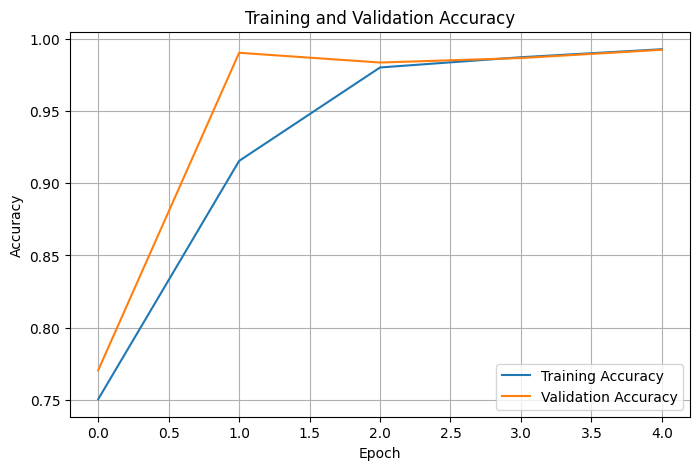

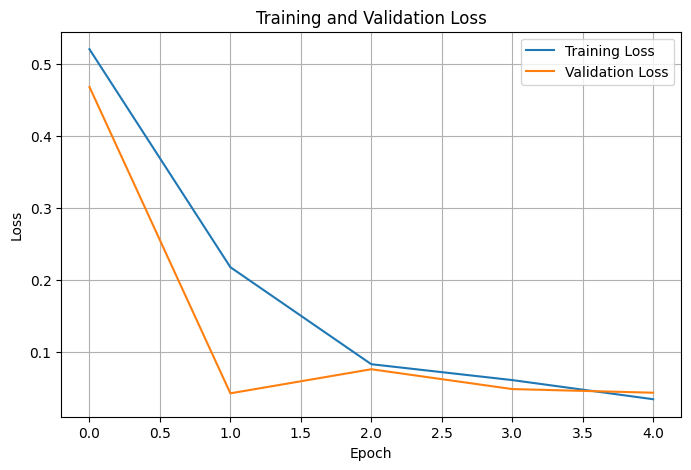

In [ ]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:

y_pred_prob = model.predict(X_test_pad)


y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

print("Predictions generated successfully!")

226/226 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step
Predictions generated successfully!


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Accuracy : 0.9920986969780982
Precision: 0.9962254655259185
Recall   : 0.989502624343914
F1-Score : 0.9928526645768025


Confusion Matrix:
[[3198   15]
 [  42 3959]]


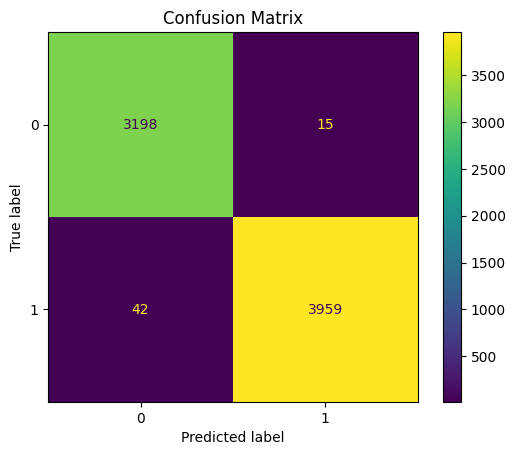

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=['Legitimate', 'Phishing/Malicious']
))

                    precision    recall  f1-score   support

        Legitimate       0.99      1.00      0.99      3213
Phishing/Malicious       1.00      0.99      0.99      4001

          accuracy                           0.99      7214
         macro avg       0.99      0.99      0.99      7214
      weighted avg       0.99      0.99      0.99      7214



In [ ]:

new_emails = [
    "Congratulations! You have won a prize. Click this link immediately to claim your reward.",
    "Hi team, please attend the project meeting tomorrow at 10 AM.",
    "Your bank account will be suspended. Verify your account immediately by clicking the link.",
    "Please find the assignment report attached. Let me know if you have any questions."
]


new_clean = [clean_text(email) for email in new_emails]


new_seq = tokenizer.texts_to_sequences(new_clean)

new_pad = pad_sequences(
    new_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)


predictions = model.predict(new_pad)

for email, prediction in zip(new_emails, predictions):
    if prediction[0] >= 0.5:
        result = "Phishing/Malicious"
    else:
        result = "Legitimate"

    print("\nEmail:", email)
    print("Prediction:", result)
    print("Probability:", round(float(prediction[0]), 4))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step

Email: Congratulations! You have won a prize. Click this link immediately to claim your reward.
Prediction: Phishing/Malicious
Probability: 0.9992

Email: Hi team, please attend the project meeting tomorrow at 10 AM.
Prediction: Legitimate
Probability: 0.0186

Email: Your bank account will be suspended. Verify your account immediately by clicking the link.
Prediction: Phishing/Malicious
Probability: 0.9992

Email: Please find the assignment report attached. Let me know if you have any questions.
Prediction: Phishing/Malicious
Probability: 0.9992


In [ ]:
print(df.groupby('label')['text'].first())

label
0    Re: svn commit: r619753 - in /spamassassin/tru...
1    Never agree to be a loser Buck up, your troubl...
Name: text, dtype: object


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=['Legitimate', 'Spam/Malicious']
))

                precision    recall  f1-score   support

    Legitimate       0.99      1.00      0.99      3213
Spam/Malicious       1.00      0.99      0.99      4001

      accuracy                           0.99      7214
     macro avg       0.99      0.99      0.99      7214
  weighted avg       0.99      0.99      0.99      7214



In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=['Legitimate', 'Spam/Malicious']
))

                precision    recall  f1-score   support

    Legitimate       0.99      1.00      0.99      3213
Spam/Malicious       1.00      0.99      0.99      4001

      accuracy                           0.99      7214
     macro avg       0.99      0.99      0.99      7214
  weighted avg       0.99      0.99      0.99      7214

